In [1]:
import sys
import os
from pathlib import Path

sys.path.append(os.path.abspath("../src"))

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from dataset import SimpleDepthDataset
from models.unet import UNet
from loss import silog_loss
from train import run_epoch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
DATA_ROOT = Path("../data/train")
TEST_ROOT = Path("../data/test")
PRED_DIR = Path("../data/preds")
CHECKPOINT_PATH = Path("../checkpoints/exp01_unet_best.pth")

os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_PATH.parent, exist_ok=True)

TRAIN_SIZE = 560
TARGET_SIZE = 560 # Required Kaggle output size
BATCH_SIZE = 6
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

In [3]:
from torch.utils.data import DataLoader, random_split

full_dataset = SimpleDepthDataset(DATA_ROOT, img_size=TRAIN_SIZE)

# 85/15 Train-Validation Split
n_val = int(0.15 * len(full_dataset))
n_train = len(full_dataset) - n_val
train_data, val_data = random_split(full_dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples: {len(train_data)} | Val samples: {len(val_data)}")

Train samples: 19215 | Val samples: 3390


In [4]:
model = UNet(n_channels=3, n_classes=1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
if CHECKPOINT_PATH.exists():
    print(f"Found existing checkpoint! Loading weights from: {CHECKPOINT_PATH}")
    model.load_state_dict(torch.load(CHECKPOINT_PATH))
else:
    print("No checkpoint found. Starting from scratch!")

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {params:,}")

Found existing checkpoint! Loading weights from: ..\checkpoints\exp01_unet_best.pth
Total trainable parameters: 31,037,633


In [5]:
train_history, val_history = [], []
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    train_loss = run_epoch(train_loader, model, optimizer=optimizer, device=DEVICE) 
    val_loss = run_epoch(val_loader, model, optimizer=None, device=DEVICE)          
    scheduler.step(val_loss)
    
    train_history.append(train_loss)
    val_history.append(val_loss)
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | Train siRMSE: {train_loss:.4f} | Val siRMSE: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> Saved new best checkpoint!")

Epoch 01/10 | Train siRMSE: 0.8735 | Val siRMSE: 0.9447
  -> Saved new best checkpoint!
Epoch 02/10 | Train siRMSE: 0.7503 | Val siRMSE: 0.6824
  -> Saved new best checkpoint!
Epoch 03/10 | Train siRMSE: 0.6780 | Val siRMSE: 0.6458
  -> Saved new best checkpoint!
Epoch 04/10 | Train siRMSE: 0.6229 | Val siRMSE: 0.6124
  -> Saved new best checkpoint!
Epoch 05/10 | Train siRMSE: 0.5792 | Val siRMSE: 0.5828
  -> Saved new best checkpoint!
Epoch 06/10 | Train siRMSE: 0.5389 | Val siRMSE: 0.5086
  -> Saved new best checkpoint!
Epoch 07/10 | Train siRMSE: 0.5031 | Val siRMSE: 0.5489
Epoch 08/10 | Train siRMSE: 0.4754 | Val siRMSE: 0.5004
  -> Saved new best checkpoint!
Epoch 09/10 | Train siRMSE: 0.4542 | Val siRMSE: 0.4882
  -> Saved new best checkpoint!
Epoch 10/10 | Train siRMSE: 0.4266 | Val siRMSE: 0.5053


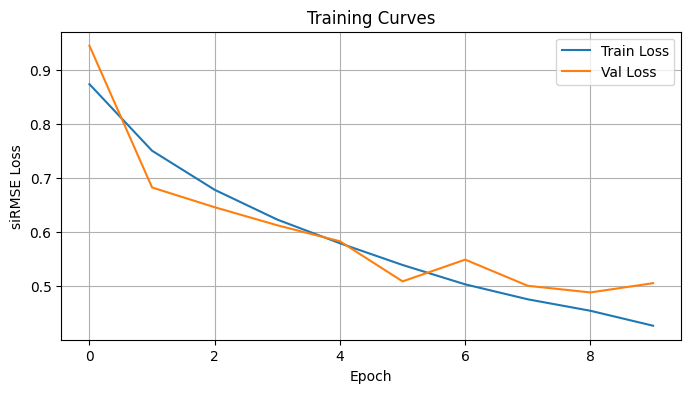

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(train_history, label="Train Loss")
plt.plot(val_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("siRMSE Loss")
plt.legend()
plt.title("Training Curves")
plt.grid(True)
plt.show()

In [7]:
print("Loading best model for inference...")
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

test_images = sorted(TEST_ROOT.glob("*_rgb.png"))
print(f"Generating predictions for {len(test_images)} test images...")

with torch.no_grad():
    for img_path in test_images:
        img = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
        img_t = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        img_t = F.interpolate(img_t, size=(TRAIN_SIZE, TRAIN_SIZE), mode="bilinear", align_corners=False)
        
        pred = model(img_t)
        
        pred_resized = F.interpolate(pred, size=(TARGET_SIZE, TARGET_SIZE), mode="bilinear", align_corners=False)
        pred_depth = pred_resized.squeeze().cpu().numpy() * 80.0
        
        # Save as .npy
        idx = img_path.stem.split("_")[1]
        np.save(PRED_DIR / f"test_{idx}.npy", pred_depth)

print(f"Ready for Kaggle! Target your submission script to: {PRED_DIR}")

Loading best model for inference...
Generating predictions for 591 test images...
Ready for Kaggle! Target your submission script to: ..\data\preds


In [8]:
import pandas as pd
import base64
import zlib

def encode_depth(depth: np.ndarray) -> str:
    depth = np.asarray(depth, dtype=np.float16)
    compressed = zlib.compress(depth.tobytes(), level=9)
    encoded = base64.b64encode(compressed).decode("utf-8")
    return encoded

pred_dir = Path("../data/preds/")   
out_csv = Path("../data/submission.csv")

rows = []
pred_files = sorted(pred_dir.glob("test_*.npy"))

for pred_path in pred_files:
    depth = np.load(pred_path)

    idx = pred_path.stem.split("_")[-1]
    img_id = f"test_{idx}_depth"

    encoded_depth = encode_depth(depth)

    rows.append({
        "id": img_id,
        "Depths": encoded_depth,
    })

df = pd.DataFrame(rows, columns=["id", "Depths"])
df.to_csv(out_csv, index=False)

print(f"Saved submission to {out_csv}")
print(f"Number of predictions: {len(df)}")

Saved submission to ..\data\submission.csv
Number of predictions: 591
